In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('exchange_rate.csv')
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [3]:
# Convert Date Column Correctly
df['date'] = pd.to_datetime(df['date'], format="%d-%m-%Y %H:%M")
df.set_index('date', inplace=True)

df.head()

,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849


In [4]:
import matplotlib.pyplot as plt

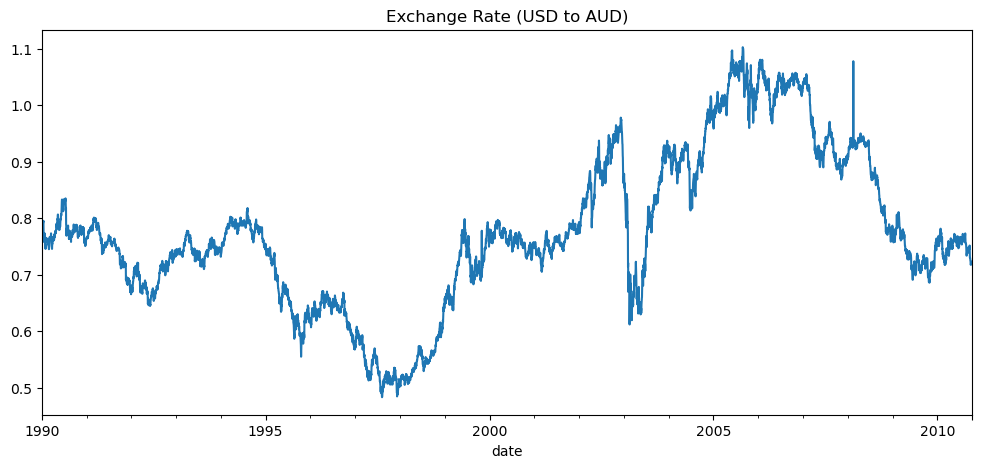

In [5]:
# Plot Time Series
df['Ex_rate'].plot(figsize=(12,5), title="Exchange Rate (USD to AUD)")
plt.show()

In [6]:
#Check for missing values
df.isna().sum()

Ex_rate    0
dtype: int64

In [7]:
from statsmodels.tsa.stattools import adfuller

In [8]:
# ADF Stationarity Test
result = adfuller(df['Ex_rate'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")


ADF Statistic: -1.6649941807381368
p-value: 0.4492327353597985
Critical Values:
   1%: -3.4312123140180137
   5%: -2.861921078147796
   10%: -2.5669728434336108


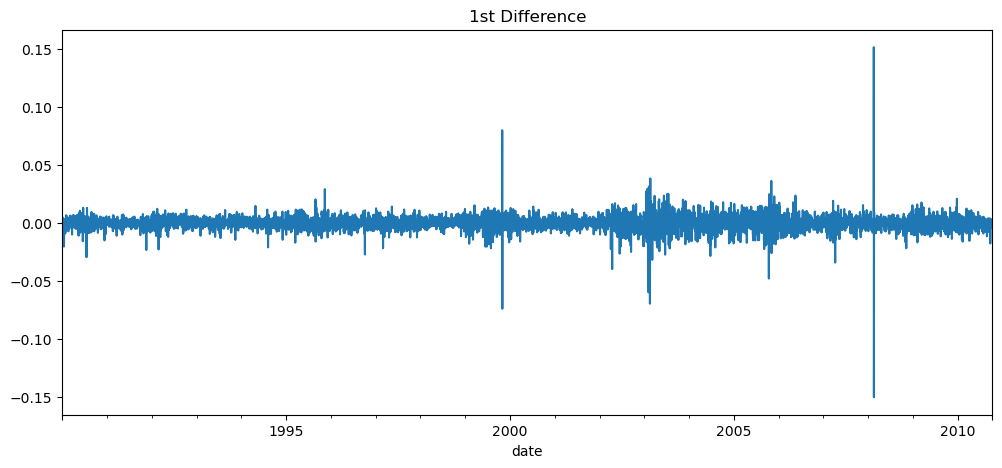

In [9]:
df_diff = df['Ex_rate'].diff().dropna()

df_diff.plot(figsize=(12,5), title="1st Difference")
plt.show()


In [10]:
 # ARIMA MODEL

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

<Figure size 1200x400 with 0 Axes>

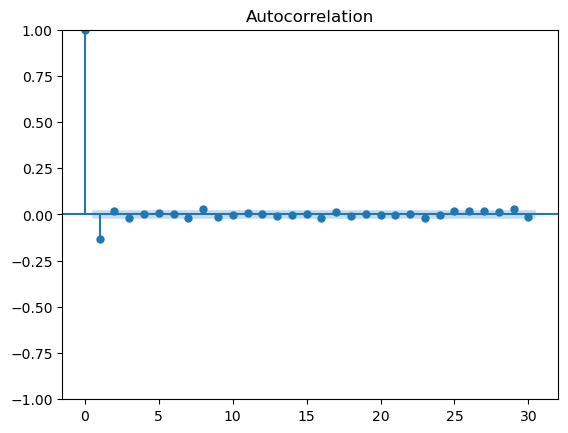

<Figure size 1200x400 with 0 Axes>

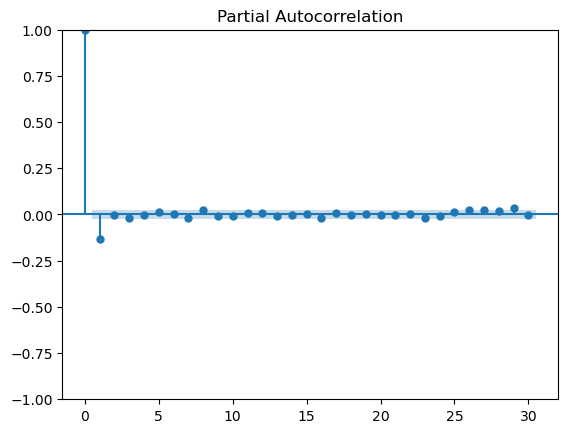

In [12]:
# ACF & PACF Plots
plt.figure(figsize=(12,4))
plot_acf(df_diff, lags=30)
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(df_diff, lags=30)
plt.show()

In [13]:
# Fit ARIMA Model
model = ARIMA(df['Ex_rate'], order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Wed, 25 Mar 2026   AIC                         -56102.322
Time:                        13:45:35   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.0

In [14]:
import seaborn as sns

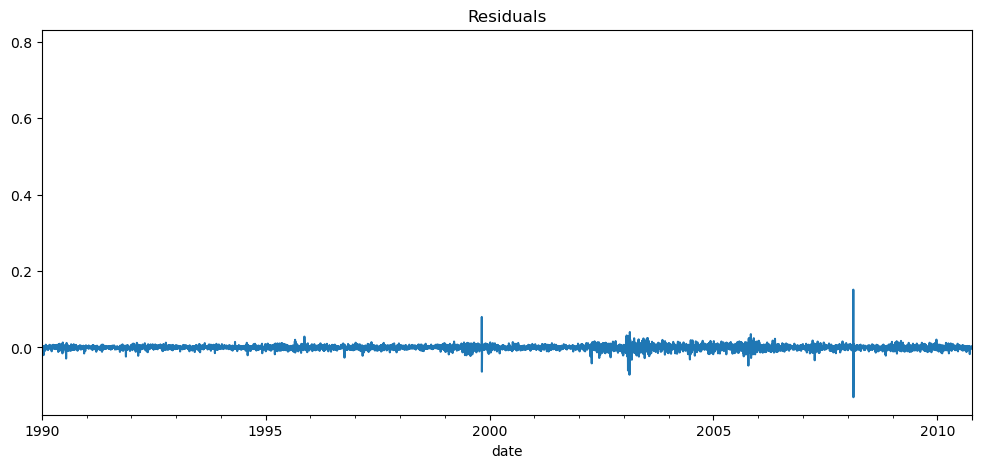

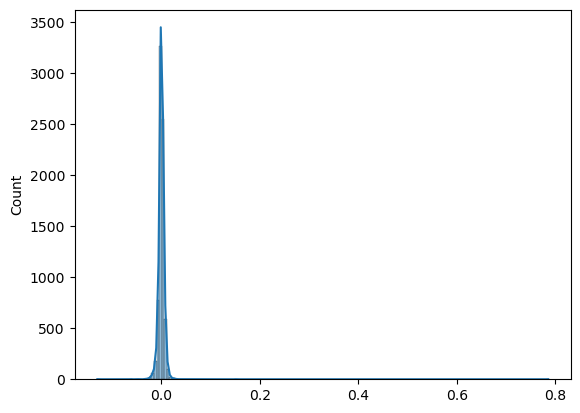

In [15]:
# Residual Diagnostics
model_fit.resid.plot(figsize=(12,5), title="Residuals")
plt.show()

sns.histplot(model_fit.resid, kde=True)
plt.show()

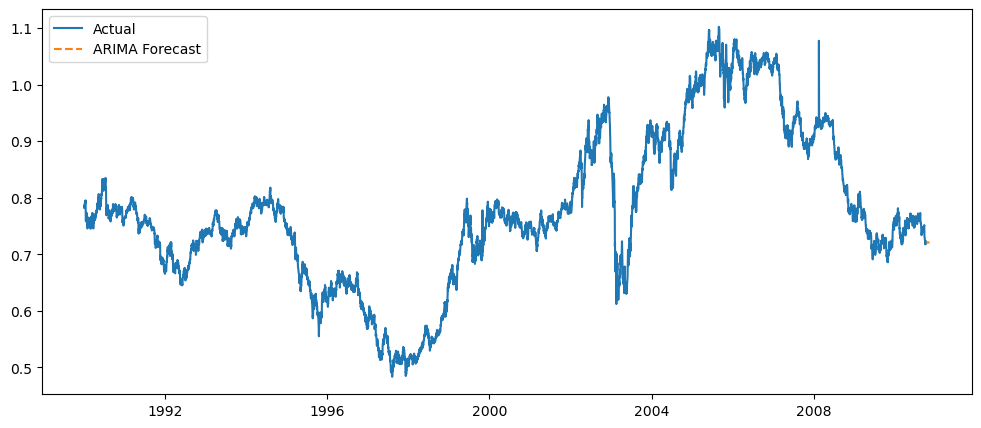

In [16]:
# Forecast Next 30 Days
forecast_arima = model_fit.forecast(30)

plt.figure(figsize=(12,5))
plt.plot(df['Ex_rate'], label="Actual")
plt.plot(forecast_arima, label="ARIMA Forecast", linestyle="--")
plt.legend()
plt.show()

In [17]:
# Fit Holt–Winters Model
hw_model = ExponentialSmoothing(
    df['Ex_rate'],
    trend='add',
    seasonal=None
).fit()

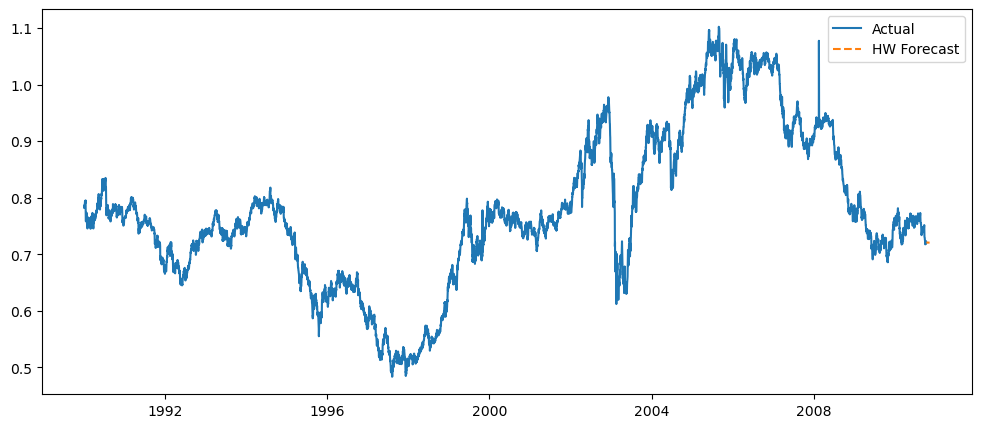

In [18]:
# Forecast 30 Days
forecast_hw = hw_model.forecast(30)

plt.figure(figsize=(12,5))
plt.plot(df['Ex_rate'], label="Actual")
plt.plot(forecast_hw, label="HW Forecast", linestyle="--")
plt.legend()
plt.show()

In [19]:
# train-test evaluation

In [20]:
train = df.iloc[:-30]
test = df.iloc[-30:]

In [21]:
#ARIMA on Training Data
model2 = ARIMA(train['Ex_rate'], order=(1,1,1))
fit2 = model2.fit()
pred_arima = fit2.forecast(30)

In [22]:
# Holt-Winters on Training Data
hw2 = ExponentialSmoothing(
    train['Ex_rate'],
    trend="add",
    seasonal=None
).fit()

pred_hw = hw2.forecast(30)

In [28]:
# Metrics Function
def metrics(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, rmse, mape

In [29]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [30]:
# Model Scores
arima_scores = metrics(test['Ex_rate'], pred_arima)
hw_scores = metrics(test['Ex_rate'], pred_hw)

print("ARIMA (MAE, RMSE, MAPE):", arima_scores)
print("Holt-Winters (MAE, RMSE, MAPE):", hw_scores)

ARIMA (MAE, RMSE, MAPE): (0.013494600805800084, np.float64(0.016632177912815297), np.float64(1.8632207485474443))
Holt-Winters (MAE, RMSE, MAPE): (0.013423166166450565, np.float64(0.016495942571767692), np.float64(1.853156135167127))


In [31]:
# model comparison

In [32]:
if arima_scores[1] < hw_scores[1]:
    print("ARIMA performs better (lower RMSE).")
else:
    print("Holt-Winters performs better (lower RMSE).")

Holt-Winters performs better (lower RMSE).
